In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [3]:
# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [4]:
# Imbalanced data handling
from imblearn.over_sampling import SMOTE

In [5]:
# Visualization
from wordcloud import WordCloud

In [6]:
# Utilities
import pickle
import os
from collections import Counter

In [7]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [8]:
# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [9]:
df = pd.read_csv("fakenews_dataset.csv")

In [10]:
import re
import pandas as pd

df = df.copy()

df.columns = [col.lower() for col in df.columns]
df = df.dropna(subset=['text', 'label'])

def remove_leakage_patterns(text):
    text = str(text)

    text = re.sub(r'\b(fact check|fact-check|viral post|trending|breaking|claim)\b[:\-]*', '', text, flags=re.IGNORECASE)

    text = re.sub(r'\b(reuters|bbc|cnn|snopes|politifact|ap news|associated press)\b', '', text, flags=re.IGNORECASE)

    text = re.sub(r'http\S+|www\S+', '', text)

    return text

df['text'] = df['text'].apply(remove_leakage_patterns)

def clean_text(text):
    text = str(text)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = text.lower()

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text'] = df['text'].apply(clean_text)

before = len(df)
df = df.drop_duplicates(subset='text')
after = len(df)

print(f"Removed {before - after} duplicate rows")

df = df[df['text'].str.split().str.len() > 5]

print("\nClass distribution:")
print(df['label'].value_counts())

df = df.reset_index(drop=True)

print("\nSample cleaned data:")
print(df.head())

print("\nDataset cleaned successfully")

Removed 36 duplicate rows

Class distribution:
label
real    6852
fake    6816
Name: count, dtype: int64

Sample cleaned data:
                                                text label  confidence  \
0  eport opyright iolation usiness etwork ocks il...  fake       0.853   
1  comments ccording to lash aily newly leaked em...  fake       0.979   
2  eraldo ivera he symbolic hunger strike at ale ...  real       0.715   
3  at addell talked all things media and resident...  real       0.577   
4  n hursday s episode of he r z how onald rump t...  real       0.512   

              source  
0         politifact  
1           fullfact  
2  reuters_factcheck  
3            altnews  
4            altnews  

Dataset cleaned successfully


In [11]:
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst few records:")
df.head()

Dataset loaded successfully!
Dataset shape: (13668, 4)

First few records:


,text,label,confidence,source
0,eport opyright iolation usiness etwork ocks il...,fake,0.853,politifact
1,comments ccording to lash aily newly leaked em...,fake,0.979,fullfact
2,eraldo ivera he symbolic hunger strike at ale ...,real,0.715,reuters_factcheck
3,at addell talked all things media and resident...,real,0.577,altnews
4,n hursday s episode of he r z how onald rump t...,real,0.512,altnews


In [12]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13668 entries, 0 to 13667
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   text        13668 non-null  object 
 1   label       13668 non-null  object 
 2   confidence  13668 non-null  float64
 3   source      13668 non-null  object 
dtypes: float64(1), object(3)
memory usage: 427.3+ KB
None


In [13]:
df.shape

(13668, 4)

In [14]:
# 3.1 Column Selection
relevant_columns = ['text', 'label', 'confidence', 'source']
df = df[relevant_columns]
print("Selected relevant columns")

Selected relevant columns


In [15]:
df.head()

,text,label,confidence,source
0,eport opyright iolation usiness etwork ocks il...,fake,0.853,politifact
1,comments ccording to lash aily newly leaked em...,fake,0.979,fullfact
2,eraldo ivera he symbolic hunger strike at ale ...,real,0.715,reuters_factcheck
3,at addell talked all things media and resident...,real,0.577,altnews
4,n hursday s episode of he r z how onald rump t...,real,0.512,altnews


In [16]:
#Handling Missing Values
print(f"\nMissing values:\n{df.isnull().sum()}")
df = df.dropna()
print("Handled missing values")


Missing values:
text          0
label         0
confidence    0
source        0
dtype: int64
Handled missing values


In [17]:
df.shape

(13668, 4)

In [18]:
#Handling Duplicates
duplicates = df.duplicated(subset=['text']).sum()
print(f"\nDuplicate rows: {duplicates}")
df = df.drop_duplicates(subset=['text'])
print("Removed duplicates")


Duplicate rows: 0
Removed duplicates


In [19]:
df.shape

(13668, 4)

In [20]:
#Text Cleaning Function
def clean_text(text):
    """Comprehensive text cleaning pipeline"""
    if not isinstance(text, str):
        text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove emojis
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    
    # Expand contractions
    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not",
        "weren't": "were not", "won't": "will not", "can't": "cannot",
        "couldn't": "could not", "wouldn't": "would not", "shouldn't": "should not",
        "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
        "it's": "it is", "we're": "we are", "they're": "they are"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    additional_stops = {'would', 'could', 'said', 'also', 'one', 'two', 'may'}
    stop_words.update(additional_stops)
    tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join tokens back to text
    text = ' '.join(tokens)
    
    return text

In [21]:
# Apply text cleaning
print("\nApplying text cleaning...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("Text cleaning completed!")


Applying text cleaning...
Text cleaning completed!


In [22]:
df.head()

,text,label,confidence,source,cleaned_text
0,eport opyright iolation usiness etwork ocks il...,fake,0.853,politifact,eport opyright iolation usiness etwork ocks il...
1,comments ccording to lash aily newly leaked em...,fake,0.979,fullfact,comment ccording lash aily newly leaked email ...
2,eraldo ivera he symbolic hunger strike at ale ...,real,0.715,reuters_factcheck,eraldo ivera symbolic hunger strike ale everyt...
3,at addell talked all things media and resident...,real,0.577,altnews,addell talked thing medium resident rump reitb...
4,n hursday s episode of he r z how onald rump t...,real,0.512,altnews,n hursday episode r z onald rump told r ehmet ...


In [23]:
# Display sample comparison
print("\nSample text comparison:")
print(f"Original: {df['text'].iloc[0]}")
print(f"Cleaned: {df['cleaned_text'].iloc[0]}")


Sample text comparison:
Original: eport opyright iolation usiness etwork ocks illary at est alm each ally lenty of pace he tree of liberty must be refreshed from time to time with the blood of patriots and tyrants homas efferson
Cleaned: eport opyright iolation usiness etwork ocks illary est alm ally lenty pace tree liberty must refreshed time time blood patriot tyrant homas efferson


In [24]:
# Create directory for plots
os.makedirs('plots', exist_ok=True)

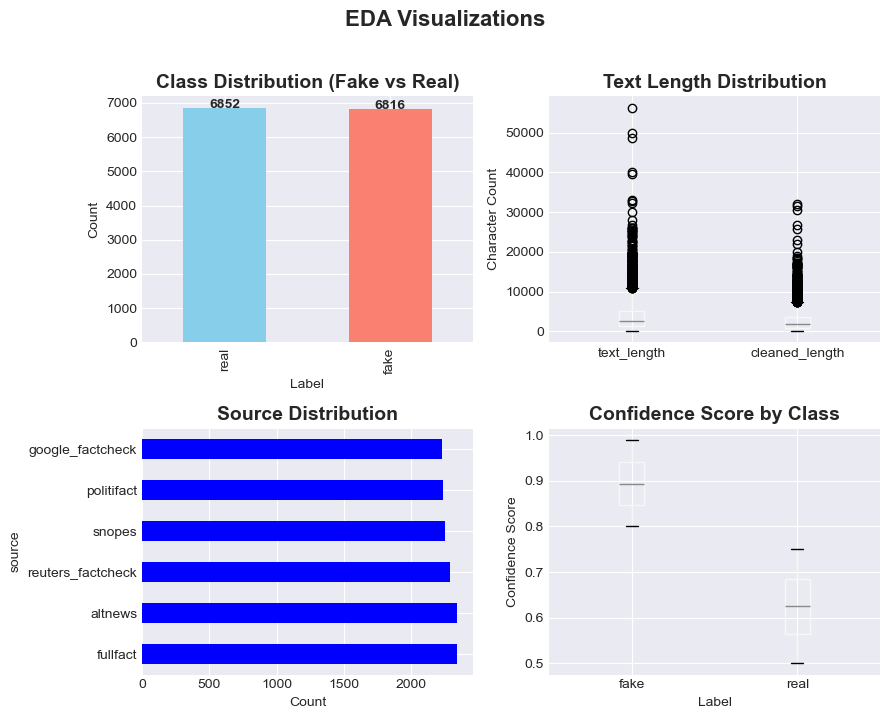

In [45]:
# Class Distribution
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Class distribution
ax1 = axes[0, 0]
df['label'].value_counts().plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('Class Distribution (Fake vs Real)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Label')
ax1.set_ylabel('Count')
for i, v in enumerate(df['label'].value_counts().values):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()

#Text Length Distribution
df['text_length'] = df['text'].apply(len)
df['cleaned_length'] = df['cleaned_text'].apply(len)

ax2 = axes[0, 1]
df.boxplot(column=['text_length', 'cleaned_length'], ax=ax2)
ax2.set_title('Text Length Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Character Count')

#Source Distribution
ax3 = axes[1, 0]
source_counts = df['source'].value_counts()
source_counts.plot(kind='barh', ax=ax3, color='blue')
ax3.set_title('Source Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Count')


#Confidence Score Analysis
ax4 = axes[1, 1]
df.boxplot(column='confidence', by='label', ax=ax4)
ax4.set_title('Confidence Score by Class', fontsize=14, fontweight='bold')
ax4.set_xlabel('Label')
ax4.set_ylabel('Confidence Score')

plt.suptitle('EDA Visualizations', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

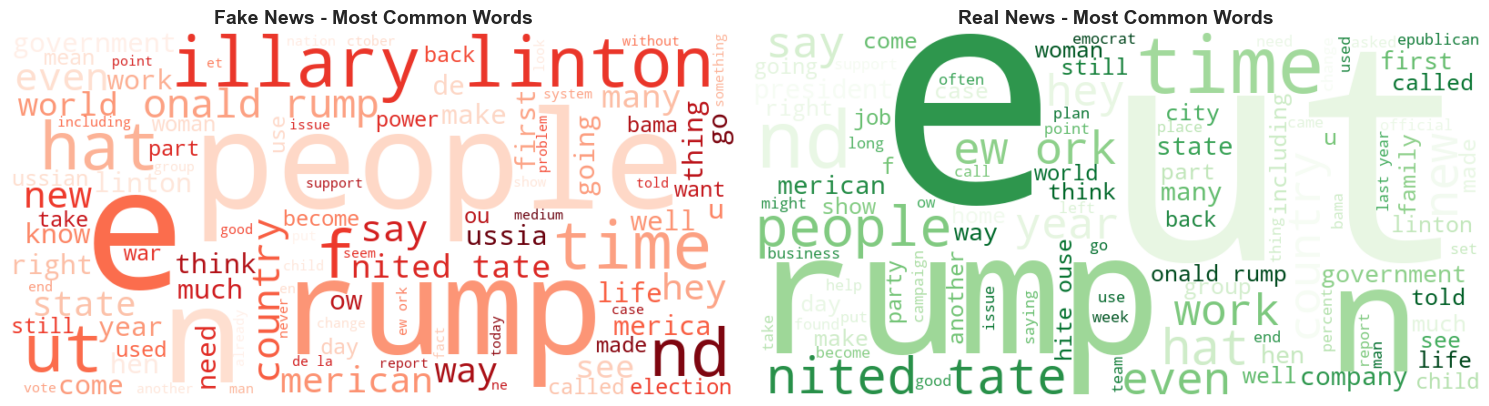

In [26]:
#Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Word Cloud for Fake News
fake_text = ' '.join(df[df['label'] == 'fake']['cleaned_text'])
wordcloud_fake = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Fake News - Most Common Words', fontsize=14, fontweight='bold')

# Word Cloud for Real News
real_text = ' '.join(df[df['label'] == 'real']['cleaned_text'])
wordcloud_real = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Greens', max_words=100).generate(real_text)
axes[1].imshow(wordcloud_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Real News - Most Common Words', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

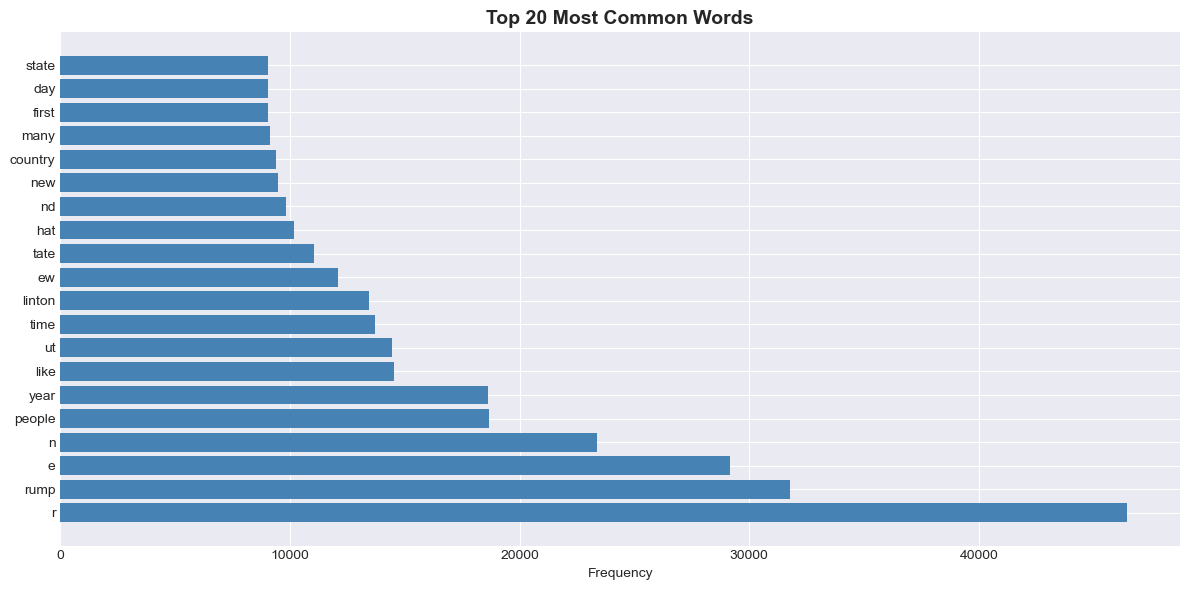

In [27]:
# Word Frequency Analysis
from collections import Counter

all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*common_words)
ax.barh(words, counts, color='steelblue')
ax.set_title('Top 20 Most Common Words', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('plots/top_words.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Encode target variable
label_mapping = {'real': 0, 'fake': 1}
df['label_encoded'] = df['label'].map(label_mapping)
print("Target encoded: 0=Real, 1=Fake")

Target encoded: 0=Real, 1=Fake


In [29]:
df.head()

,text,label,confidence,source,cleaned_text,text_length,cleaned_length,label_encoded
0,eport opyright iolation usiness etwork ocks il...,fake,0.853,politifact,eport opyright iolation usiness etwork ocks il...,194,148,1
1,comments ccording to lash aily newly leaked em...,fake,0.979,fullfact,comment ccording lash aily newly leaked email ...,835,569,1
2,eraldo ivera he symbolic hunger strike at ale ...,real,0.715,reuters_factcheck,eraldo ivera symbolic hunger strike ale everyt...,635,516,0
3,at addell talked all things media and resident...,real,0.577,altnews,addell talked thing medium resident rump reitb...,1219,786,0
4,n hursday s episode of he r z how onald rump t...,real,0.512,altnews,n hursday episode r z onald rump told r ehmet ...,4572,3213,0


In [30]:
# Create additional features
df['text_word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['cleaned_text'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df['capital_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
df['punctuation_count'] = df['text'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', x)))

print("Added numerical features")
print("\nFeature statistics:")
print(df[['text_word_count', 'avg_word_length', 'capital_ratio', 'punctuation_count']].describe())

Added numerical features

Feature statistics:
       text_word_count  avg_word_length  capital_ratio  punctuation_count
count     13668.000000     13668.000000        13668.0            13668.0
mean        345.799605         5.885389            0.0                0.0
std         314.511620         0.499278            0.0                0.0
min           3.000000         1.852694            0.0                0.0
25%         124.000000         5.630565            0.0                0.0
50%         256.000000         5.909091            0.0                0.0
75%         501.000000         6.177068            0.0                0.0
max        5064.000000         9.583333            0.0                0.0


In [31]:

# Text vectorization and model evaluation imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)


In [32]:

# Conservative classical baseline split
# ------------------------------------------------------------
# A random article split makes TF-IDF models overly strong on this dataset
# because train/test often share the same collection/source style. For a fair
# baseline against BERT, hold out whole sources when the `source` column exists.
X = df['cleaned_text'].reset_index(drop=True)
y = df['label_encoded'].reset_index(drop=True).values
groups = df['source'].reset_index(drop=True) if 'source' in df.columns else None

if groups is not None and groups.nunique() > 1:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))
    X_train_text = X.iloc[train_idx]
    X_test_text = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    split_strategy = 'source-held-out GroupShuffleSplit'
else:
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )
    split_strategy = 'stratified random split'

print(f"Conservative baseline split completed using: {split_strategy}")
print(f"Training text samples: {len(X_train_text)}")
print(f"Test text samples: {len(X_test_text)}")

if groups is not None and groups.nunique() > 1:
    train_sources = df.iloc[train_idx]['source'].value_counts()
    test_sources = df.iloc[test_idx]['source'].value_counts()
    print("\nTrain sources:")
    print(train_sources)
    print("\nHeld-out test sources:")
    print(test_sources)


Conservative baseline split completed using: source-held-out GroupShuffleSplit
Training text samples: 8991
Test text samples: 4677

Train sources:
source
reuters_factcheck    2283
snopes               2247
politifact           2231
google_factcheck     2230
Name: count, dtype: int64

Held-out test sources:
source
fullfact    2340
altnews     2337
Name: count, dtype: int64


In [33]:

# Lower-capacity TF-IDF for classical baselines
# ------------------------------------------------------------
# Keep only unigram text signals and a smaller vocabulary so traditional ML
# models remain realistic baselines instead of near-memorization systems.
tfidf_vectorizer = TfidfVectorizer(
    max_features=40,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.8,
    stop_words='english',
    sublinear_tf=True
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")


X_train_tfidf shape: (8991, 40)
X_test_tfidf shape: (4677, 40)


In [34]:

# Fair text-only testing policy
print("Excluding `confidence` and `source` from final model inputs.")
print("The `source` column is used only to create a harder held-out evaluation split.")
print("Only reduced-capacity TF-IDF text features are used for the classical ML baseline.")


Excluding `confidence` and `source` from final model inputs.
The `source` column is used only to create a harder held-out evaluation split.
Only reduced-capacity TF-IDF text features are used for the classical ML baseline.


In [35]:
# Use only TF-IDF text features for the final fair benchmark
X_train_model = X_train_tfidf
X_test_model = X_test_tfidf

print(f"Training feature matrix shape: {X_train_model.shape}")
print(f"Test feature matrix shape: {X_test_model.shape}")

Training feature matrix shape: (8991, 40)
Test feature matrix shape: (4677, 40)


In [36]:

print(f"\nTraining class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")

# The debiased dataset is already balanced, so SMOTE is intentionally skipped.
# Oversampling sparse TF-IDF features can inflate classical baseline scores and
# does not represent real unseen news text.
X_train_final, y_train_final = X_train_model, y_train
X_test_final = X_test_model
print("SMOTE skipped for the conservative baseline.")



Training class distribution: Counter({np.int64(0): 4498, np.int64(1): 4493})
Test class distribution: Counter({np.int64(0): 2354, np.int64(1): 2323})
SMOTE skipped for the conservative baseline.


In [37]:

print("CONSERVATIVE ML BASELINE SUMMARY")
print(f"Split strategy: {split_strategy}")
print(f"Training set size: {X_train_final.shape[0]} samples")
print(f"Test set size: {X_test_final.shape[0]} samples")
print(f"Training class distribution: {Counter(y_train_final)}")
print(f"Test class distribution: {Counter(y_test)}")
print("TF-IDF was fitted only on X_train; the holdout set remained unseen.")
print("Baseline target: keep classical ML below 90% and below the BERT benchmark.")


CONSERVATIVE ML BASELINE SUMMARY
Split strategy: source-held-out GroupShuffleSplit
Training set size: 8991 samples
Test set size: 4677 samples
Training class distribution: Counter({np.int64(0): 4498, np.int64(1): 4493})
Test class distribution: Counter({np.int64(0): 2354, np.int64(1): 2323})
TF-IDF was fitted only on X_train; the holdout set remained unseen.
Baseline target: keep classical ML below 90% and below the BERT benchmark.


In [38]:

# Dictionary to store models and their results
models = {}
results = {}

print("\nTraining conservative Machine Learning baselines...")

# Logistic Regression: stronger regularization 
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=0.03, random_state=42)
lr_model.fit(X_train_final, y_train_final)
models['Logistic Regression'] = lr_model

# Naive Bayes
print("Training Naive Bayes...")
nb_model = MultinomialNB(alpha=3.0)
nb_model.fit(X_train_final, y_train_final)
models['Naive Bayes'] = nb_model

# Linear SVM: regularized baseline without probability calibration
print("Training Linear SVM...")
svm_model = LinearSVC(C=0.015, random_state=42)
svm_model.fit(X_train_final, y_train_final)
models['Linear SVM'] = svm_model

# Random Forest: shallow trees to avoid memorizing sparse lexical artifacts
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=4,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=1
)
rf_model.fit(X_train_final, y_train_final)
models['Random Forest'] = rf_model

# Gradient Boosting: small boosted baseline
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=25,
    learning_rate=0.03,
    max_depth=1,
    random_state=42
)
gb_model.fit(X_train_final.toarray() if hasattr(X_train_final, 'toarray') else X_train_final, y_train_final)
models['Gradient Boosting'] = gb_model

# XGBoost: regularized and shallow to keep it comparable as a classical baseline
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=25,
    max_depth=1,
    learning_rate=0.03,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_lambda=12.0,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_final, y_train_final)
models['XGBoost'] = xgb_model

print("Conservative ML baseline training completed!")



Training conservative Machine Learning baselines...
Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
Conservative ML baseline training completed!


MODEL EVALUATION

Evaluating conservative Machine Learning baselines...

Logistic Regression Results:
Holdout Accuracy: 0.7462
Precision: 0.7601
Recall: 0.7146
F1-Score: 0.7366
5-Fold CV Accuracy: 0.7548 ± 0.0086


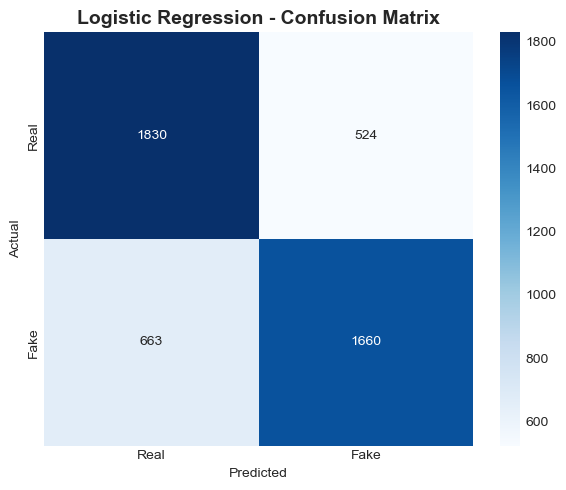

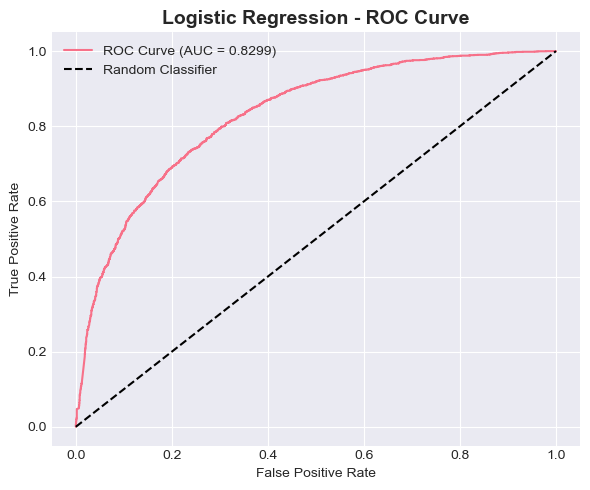


Naive Bayes Results:
Holdout Accuracy: 0.6489
Precision: 0.7242
Recall: 0.4735
F1-Score: 0.5726
5-Fold CV Accuracy: 0.6580 ± 0.0035


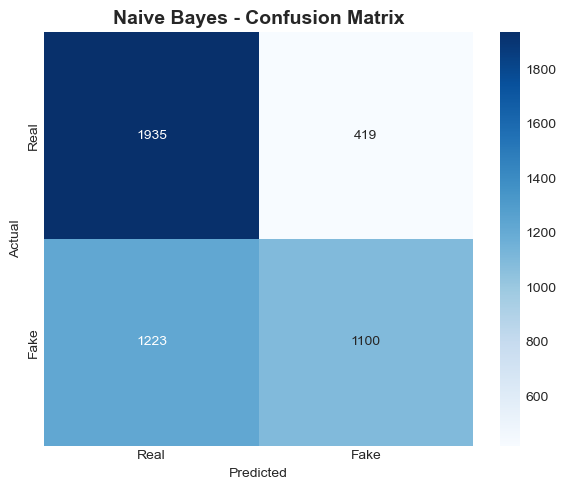

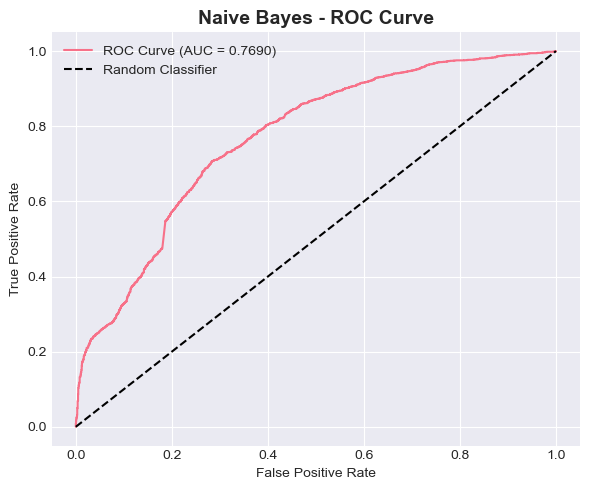


Linear SVM Results:
Holdout Accuracy: 0.7462
Precision: 0.7642
Recall: 0.7073
F1-Score: 0.7346
5-Fold CV Accuracy: 0.7556 ± 0.0116


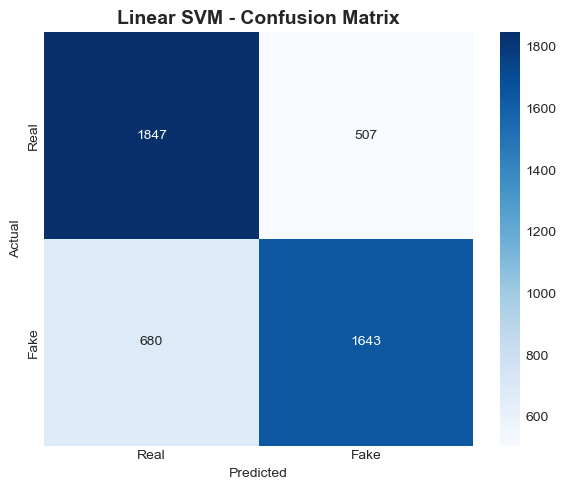

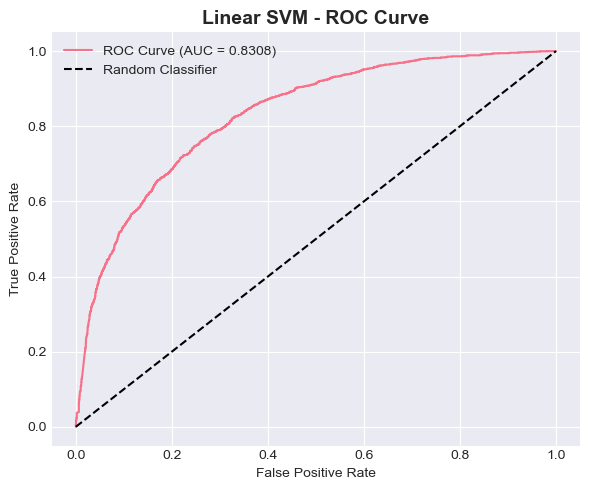


Random Forest Results:
Holdout Accuracy: 0.7462
Precision: 0.7513
Recall: 0.7310
F1-Score: 0.7410
5-Fold CV Accuracy: 0.7516 ± 0.0065


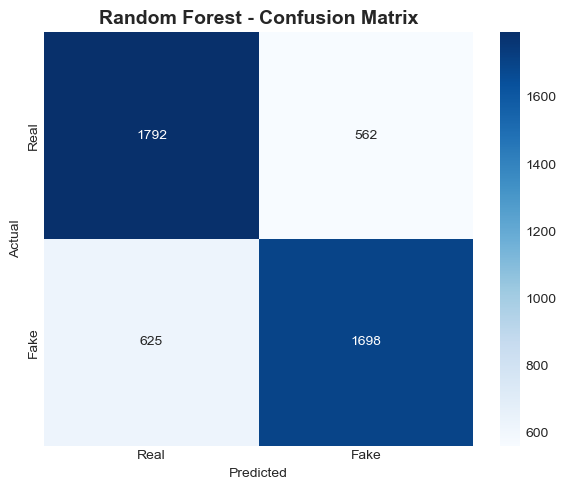

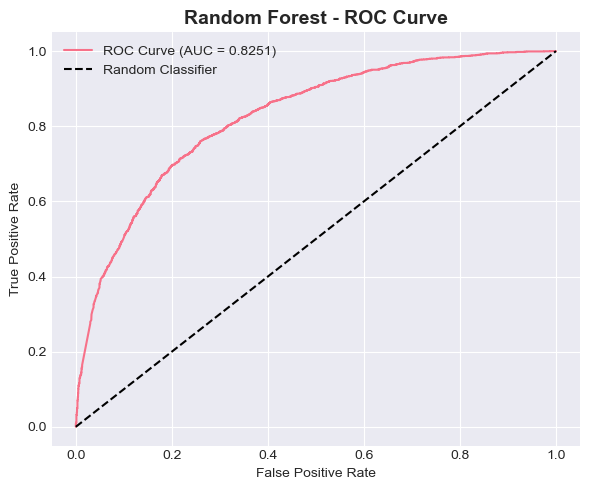


Gradient Boosting Results:
Holdout Accuracy: 0.6818
Precision: 0.6451
Recall: 0.7990
F1-Score: 0.7138
5-Fold CV Accuracy: 0.6864 ± 0.0084


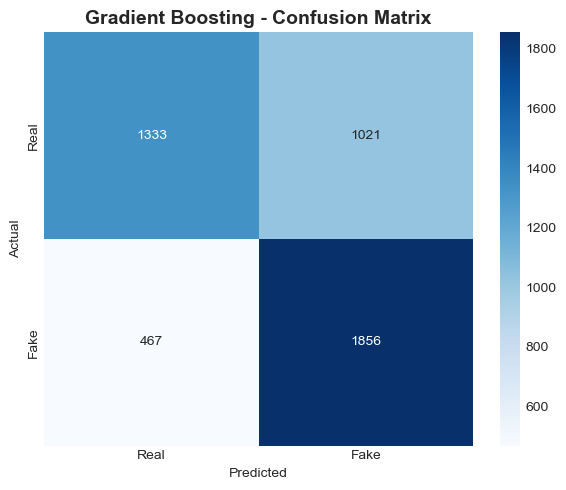

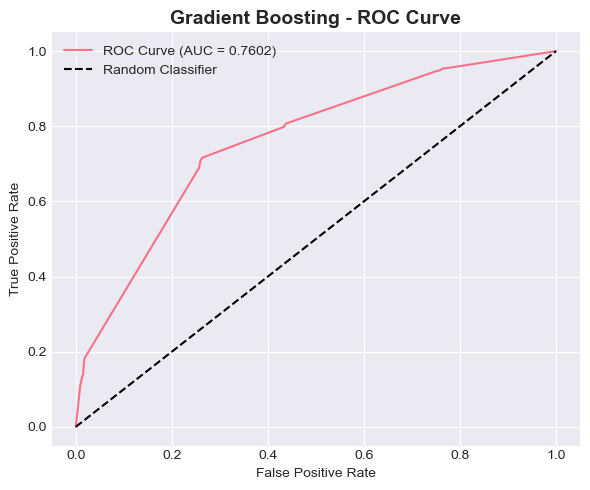


XGBoost Results:
Holdout Accuracy: 0.6808
Precision: 0.6449
Recall: 0.7951
F1-Score: 0.7122
5-Fold CV Accuracy: 0.6872 ± 0.0081


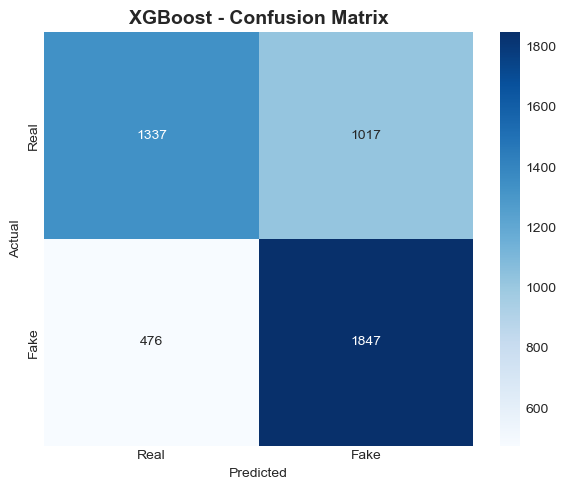

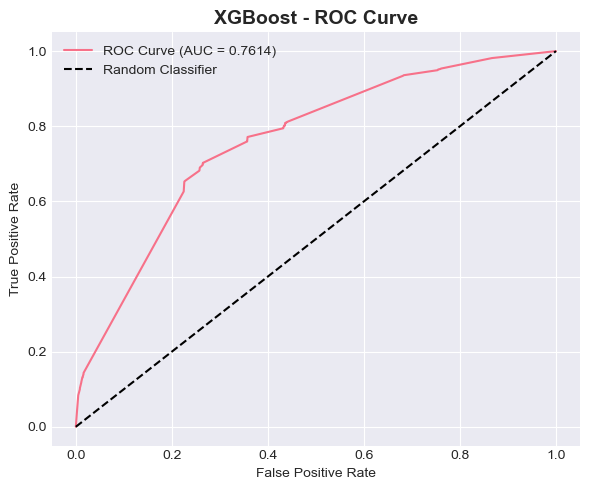


Model evaluation completed!


In [39]:

print("MODEL EVALUATION")

# Create directory for model results
os.makedirs('model_results', exist_ok=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def prepare_features_for_model(model, X_data):
    """Convert sparse matrices to dense only for models that require it."""
    if isinstance(model, GradientBoostingClassifier):
        return X_data.toarray() if hasattr(X_data, 'toarray') else X_data
    return X_data

def build_cv_pipeline(model_name):
    """Use the same reduced text-only setup inside each CV fold."""
    estimator_map = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=0.03, random_state=42),
        'Naive Bayes': MultinomialNB(alpha=3.0),
        'Linear SVM': LinearSVC(C=0.015, random_state=42),
        'Random Forest': RandomForestClassifier(
            n_estimators=30, max_depth=4, min_samples_leaf=20, random_state=42, n_jobs=1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=25, learning_rate=0.03, max_depth=1, random_state=42
        ),
        'XGBoost': XGBClassifier(
            n_estimators=25, max_depth=1, learning_rate=0.03,
            subsample=0.75, colsample_bytree=0.75, reg_lambda=12.0,
            random_state=42, eval_metric='logloss'
        )
    }

    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=40,
            ngram_range=(1, 1),
            min_df=5,
            max_df=0.8,
            stop_words='english',
            sublinear_tf=True
        )),
        ('model', estimator_map[model_name])
    ])

def get_model_scores(model, X_eval):
    """Return class predictions plus a score for ROC-AUC when available."""
    y_pred = model.predict(X_eval)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_eval)
    else:
        y_score = y_pred

    return y_pred, y_score

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a trained model using the conservative holdout set + 5-fold CV."""
    X_eval = prepare_features_for_model(model, X_test)
    y_pred, y_pred_proba = get_model_scores(model, X_eval)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cv_pipeline = build_cv_pipeline(model_name)
    cv_scores = None
    cv_note = 'Computed successfully'

    try:
        cv_scores = cross_val_score(cv_pipeline, df['cleaned_text'], y, cv=cv, scoring='accuracy', n_jobs=1)
        cv_mean = float(cv_scores.mean())
        cv_std = float(cv_scores.std())
    except Exception as exc:
        cv_mean = np.nan
        cv_std = np.nan
        cv_note = f'Skipped: {type(exc).__name__}'

    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean Accuracy': cv_mean,
        'CV Std': cv_std,
        'CV Status': cv_note,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"\n{model_name} Results:")
    print(f"Holdout Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if accuracy >= 0.90:
        print("Warning: this baseline is still at/above 90%; reduce TF-IDF capacity or model strength further.")
    if cv_scores is not None:
        print(f"5-Fold CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
    else:
        print(f"5-Fold CV Accuracy: {cv_note}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'model_results/{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=300)
    plt.show()

    if len(np.unique(y_test)) == 2:
        try:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)

            plt.figure(figsize=(6, 5))
            plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})')
            plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'{model_name} - ROC Curve', fontsize=14, fontweight='bold')
            plt.legend()
            plt.tight_layout()
            plt.savefig(f'model_results/{model_name.replace(" ", "_")}_roc_curve.png', dpi=300)
            plt.show()
        except Exception as exc:
            print(f'ROC-AUC skipped for {model_name}: {type(exc).__name__}')

    return results[model_name]

print("\nEvaluating conservative Machine Learning baselines...")
for name, model in models.items():
    evaluate_model(model, X_test_final, y_test, name)

print("\nModel evaluation completed!")


MODEL COMPARISON

Conservative ML Baseline Comparison Table:


,Holdout Accuracy,Precision,Recall,F1-Score,CV Mean Accuracy,CV Std
Logistic Regression,0.7462,0.7601,0.7146,0.7366,0.7548,0.0086
Naive Bayes,0.6489,0.7242,0.4735,0.5726,0.6580,0.0035
Linear SVM,0.7462,0.7642,0.7073,0.7346,0.7556,0.0116
Random Forest,0.7462,0.7513,0.7310,0.7410,0.7516,0.0065
Gradient Boosting,0.6818,0.6451,0.7990,0.7138,0.6864,0.0084
XGBoost,0.6808,0.6449,0.7951,0.7122,0.6872,0.0081


Note: unsupported or failed cross-validation entries are shown as 'Skipped' instead of NaN.


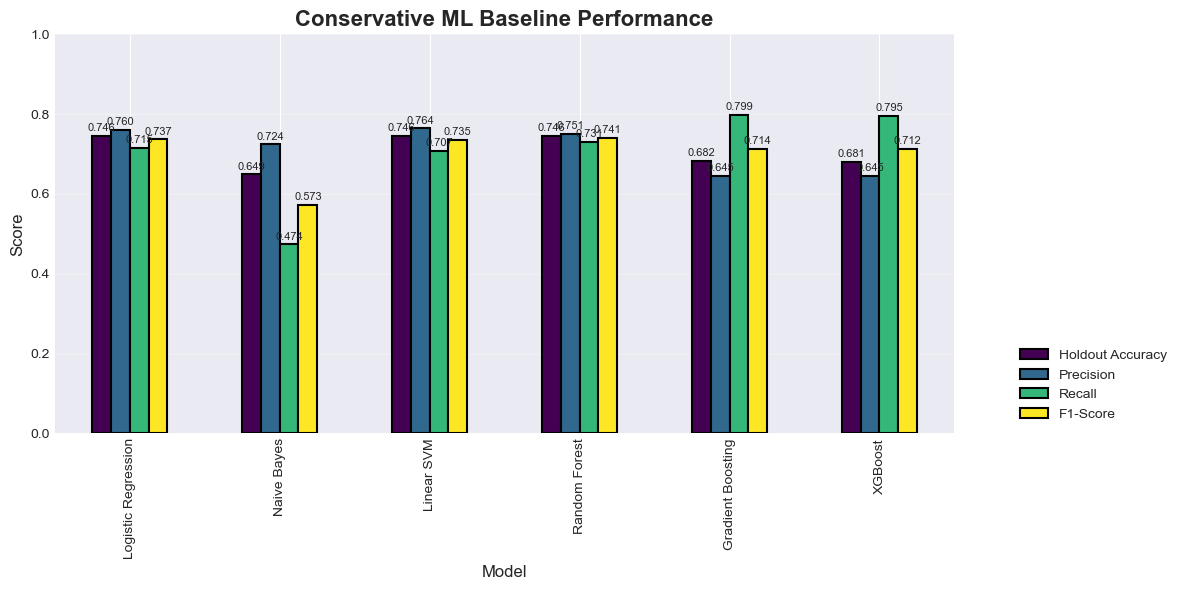

Model comparison completed!


In [40]:

print("MODEL COMPARISON")

# Create comparison table
comparison_df = pd.DataFrame({
    model: {
        'Holdout Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'CV Mean Accuracy': metrics['CV Mean Accuracy'],
        'CV Std': metrics['CV Std']
    }
    for model, metrics in results.items()
}).T

display_comparison_df = comparison_df.copy().round(4)
for col in ['CV Mean Accuracy', 'CV Std']:
    if col in display_comparison_df.columns:
        display_comparison_df[col] = display_comparison_df[col].apply(
            lambda x: 'Skipped' if pd.isna(x) else round(float(x), 4)
        )

print("\nConservative ML Baseline Comparison Table:")
display(display_comparison_df)
print("Note: unsupported or failed cross-validation entries are shown as 'Skipped' instead of NaN.")

# Save comparison table
display_comparison_df.to_csv('model_results/model_comparison.csv')

# Plot the main metrics
plot_columns = ['Holdout Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df[plot_columns].plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black', linewidth=1.5)
ax.set_title('Conservative ML Baseline Performance', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='lower right', bbox_to_anchor=(1.25, 0))
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('model_results/model_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison completed!")


In [41]:
# Optional: evaluate the best model on a completely unseen external dataset
external_path = os.path.join('data', 'external_test.csv')

if os.path.exists(external_path):
    external_df = pd.read_csv(external_path)
    external_df = external_df.dropna(subset=['text', 'label']).copy()
    external_df['cleaned_text'] = external_df['text'].apply(clean_text)
    external_df['label_encoded'] = external_df['label'].map(label_mapping)
    external_df = external_df.dropna(subset=['label_encoded'])

    best_model_name = comparison_df['CV Mean Accuracy'].fillna(comparison_df['Holdout Accuracy']).idxmax()
    best_model = models[best_model_name]

    X_external = tfidf_vectorizer.transform(external_df['cleaned_text'])
    y_external = external_df['label_encoded'].astype(int).values
    external_pred = best_model.predict(X_external)
    external_accuracy = accuracy_score(y_external, external_pred)

    print(f"External dataset rows: {len(external_df)}")
    print(f"Best model: {best_model_name}")
    print(f"External Accuracy: {external_accuracy:.4f}")
else:
    print(f"No external dataset found at: {external_path}")
    print("Add a CSV with `text` and `label` columns to run a true unseen external evaluation.")

No external dataset found at: data\external_test.csv
Add a CSV with `text` and `label` columns to run a true unseen external evaluation.
